In [1]:
!pip install optuna
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             )
from catboost import CatBoostRegressor, Pool
import optuna
import seaborn as sns



In [7]:
df_raw = pd.read_csv('training_data_02_01.csv')
df_raw.shape
df_raw = df_raw.sample(n=1_000_000, random_state=42)

In [8]:
df_raw["Rating"].max()

3238.0

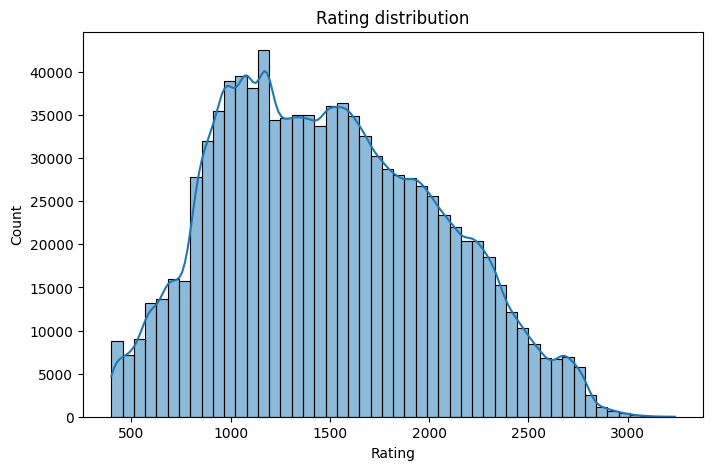

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_raw["Rating"], bins=50, kde=True)
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Поставим задачу
Сосредоточим свои силы, чтобы уменьшить скор модели. Будем мерить по MAE, так как таргет распределен нормально, а значит намного важнее хорошо определять рейтинг задачи в районе ~1500, чем пытаться хорошо отработать на 2500, где и людей намного меньше

In [10]:
df_raw['FEN'].head()

,FEN
670598,2r4r/pp3k2/4p1p1/8/5b1B/2NQ2P1/PPP2q2/R3R2K w ...
8571,r4rk1/pbqn1ppp/1p1bp3/2p1NP2/2p2BP1/P1NP3P/1PP...
235238,2krr3/1ppq1pp1/1p5p/1n1p4/QP2n3/P3B1P1/4PPBP/2...
611455,8/8/7p/7P/3pp3/3N4/2k1K3/8 w - - 8 56
875277,r6k/p1pp2pp/bpn4q/2b3N1/4N3/4P3/PPP2PPP/2KR1B1...


### Базовая генерация признаков:

Создадим базовые агрегации и вытащим длину решения. Парсинг FEN  пока опустим, чтобы не перегружать бейзлайн (однако в будущем оттуда можно извлечь баланс материала). Плюсом, также оставим на потом работу с темами задач.

In [11]:
def preprocess_data(df):
    data = df.copy()

    prob_cols = [col for col in data.columns if col.startswith('success_prob')]

    data['prob_mean'] = data[prob_cols].mean(axis=1)
    data['prob_min'] = data[prob_cols].min(axis=1)
    data['prob_max'] = data[prob_cols].max(axis=1)
    data['prob_std'] = data[prob_cols].std(axis=1)

    data['moves_count'] = data['Moves'].apply(lambda x: len(str(x).split()))

    data['themes_count'] = data['Themes'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

    cols_to_drop = ["Rating", "OpeningTags", "PuzzleId", "FEN", "Moves", "Themes", "GameUrl"]
    X = data.drop(columns=cols_to_drop, inplace=False)
    y = data["Rating"]

    return X, y

X, y = preprocess_data(df_raw)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
y_train.isna().sum()
y_train = y_train.fillna(y_train.median())

### Baseline модель
Для начала обучим простую линейную модель (Ridge), чтобы задать начальную планку качества. Она работает быстро и покажет, насколько хорошо таргет предсказывается простыми линейными зависимостями от вероятностей движка.

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('ridge', Ridge(alpha=0.5))
])

pipeline.fit(X_train, y_train)

preds_baseline = pipeline.predict(X_test)

mae_base = mean_absolute_error(y_test, preds_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, preds_baseline))

print(f"Baseline Ridge MAE: {mae_base:.2f}")
print(f"Baseline Ridge RMSE: {rmse_base:.2f}")

Baseline Ridge MAE: 289.00
Baseline Ridge RMSE: 362.53


Получили +- неплохой скор (ошибаемся на ~300 эло). На RMSE вообще 360 эло

###Продвинутая модель (CatBoost) + Подбор гиперпараметров
Так как зависимости в рейтинге вряд ли линейные, используем градиентный бустинг. CatBoost хорошее решение предлагает даже из коробки + кодирование категориальных фичей может неплохо помочь

In [18]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'RMSE',
        'eval_metric': 'MAE',
        'random_seed': 42,
        'verbose': False,

    }

    X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=50000, random_state=42)
    X_t, X_v, y_t, y_v = train_test_split(X_tune, y_tune, test_size=0.2, random_state=42)

    model = CatBoostRegressor(**params)
    model.fit(X_t, y_t, eval_set=(X_v, y_v), early_stopping_rounds=50)
    preds = model.predict(X_v)
    return mean_absolute_error(y_v, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=11)
print("Лучшие параметры:", study.best_params)

best_params = study.best_params
final_model = CatBoostRegressor(**best_params, loss_function='RMSE', eval_metric='MAE', verbose=50)
final_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100)

final_preds = final_model.predict(X_test)
print(f"Финальный CatBoost MAE: {mean_absolute_error(y_test, final_preds):.2f}")

[I 2026-03-17 13:25:53,363] A new study created in memory with name: no-name-d5ecd5e4-ae36-4c5a-88bb-cdecded54d83
[I 2026-03-17 13:26:07,958] Trial 0 finished with value: 227.38118415088528 and parameters: {'iterations': 1093, 'learning_rate': 0.030102687279102362, 'depth': 3, 'l2_leaf_reg': 5.221733362591738}. Best is trial 0 with value: 227.38118415088528.
[I 2026-03-17 13:26:21,737] Trial 1 finished with value: 222.6683327743615 and parameters: {'iterations': 1365, 'learning_rate': 0.05533514513437803, 'depth': 3, 'l2_leaf_reg': 9.5566449295127}. Best is trial 1 with value: 222.6683327743615.
[I 2026-03-17 13:26:35,816] Trial 2 finished with value: 232.1722990981957 and parameters: {'iterations': 1406, 'learning_rate': 0.011575283695688079, 'depth': 3, 'l2_leaf_reg': 4.710454553349326}. Best is trial 1 with value: 222.6683327743615.
[I 2026-03-17 13:26:50,567] Trial 3 finished with value: 227.4063114045702 and parameters: {'iterations': 1209, 'learning_rate': 0.013791046452232019, '

Лучшие параметры: {'iterations': 996, 'learning_rate': 0.061689367765939467, 'depth': 8, 'l2_leaf_reg': 5.895607279906968}
0:	learn: 436.3054063	test: 435.3798660	best: 435.3798660 (0)	total: 425ms	remaining: 7m 2s
50:	learn: 231.9859486	test: 232.6765510	best: 232.6765510 (50)	total: 15.2s	remaining: 4m 41s
100:	learn: 223.0404391	test: 223.7730736	best: 223.7730736 (100)	total: 29.4s	remaining: 4m 20s
150:	learn: 219.6885838	test: 220.4516222	best: 220.4516222 (150)	total: 43.8s	remaining: 4m 4s
200:	learn: 217.5937018	test: 218.4019398	best: 218.4019398 (200)	total: 58s	remaining: 3m 49s
250:	learn: 215.6553073	test: 216.5182592	best: 216.5182592 (250)	total: 1m 12s	remaining: 3m 35s
300:	learn: 214.2407922	test: 215.1514590	best: 215.1514590 (300)	total: 1m 26s	remaining: 3m 20s
350:	learn: 213.0802757	test: 214.0477167	best: 214.0477167 (350)	total: 1m 41s	remaining: 3m 6s
400:	learn: 212.2413491	test: 213.2753698	best: 213.2753698 (400)	total: 1m 55s	remaining: 2m 51s
450:	learn:

Получаем примерно ошибку в 210 пунктов рейтинга, попробуем улучшить фичи и поменять функционал ошибки

### Идея
Т.к. у таргета медиана около 1400~ эло, возьмем медианный порог (то есть если acceptance rate > 0,35 считаем, что это примерно рейтинг игрока)

In [23]:
prob_cols = [col for col in df_raw.columns if col.startswith('success_prob')]
df_raw[prob_cols].median()

,0
success_prob_rapid_1050,0.248370
success_prob_rapid_1150,0.302300
success_prob_rapid_1250,0.318270
success_prob_rapid_1350,0.334622
success_prob_rapid_1450,0.348736
success_prob_rapid_1550,0.357192
success_prob_rapid_1650,0.366439
success_prob_rapid_1750,0.372599
success_prob_rapid_1850,0.375278
success_prob_rapid_1950,0.376779


### Пытаемся выжать больше информации из данных

Работаем над колонкой Themes, из которой извлекаем уже не количество тем, а сами темы. Также пытаемся распарсить качество первого хода: был ли он очевиден или нет. + Пытаемся использовать информацию, на каком именно рейтинге поднялось кол-во решений

In [21]:
def preprocess_data_advanced(df):
    data = df.copy()

    prob_cols = [col for col in data.columns if col.startswith('success_prob')]

    data['moves_count'] = data['Moves'].apply(lambda x: len(str(x).split()))
    data['themes_count'] = data['Themes'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

    data['Themes_text'] = data['Themes'].fillna('').apply(lambda x: str(x).replace(',', ' '))

    probs_array = data[prob_cols].values
    thresholds = []
    for row in probs_array:
        idx = np.where(row > 0.35)[0]
        thresholds.append(idx[0] if len(idx) > 0 else len(row))
    data['threshold_35_idx'] = thresholds

    gradients = data[prob_cols].diff(axis=1).fillna(0)
    data['grad_max'] = gradients.max(axis=1)
    data['grad_mean'] = gradients.mean(axis=1)

    def parse_first_move(moves_str):
        if pd.isna(moves_str):
            return 0, 0, 0
        moves = str(moves_str).split()
        if len(moves) < 2:
            return 0, 0, 0

        player_first_move = moves[1]

        is_capture = int('x' in player_first_move)
        is_check = int('+' in player_first_move)
        is_promotion = int('=' in player_first_move or (len(player_first_move) == 5 and player_first_move[-1].isalpha()))

        return is_capture, is_check, is_promotion

    parsed_moves = data['Moves'].apply(parse_first_move)
    data['player_first_move_capture'] = [x[0] for x in parsed_moves]
    data['player_first_move_check'] = [x[1] for x in parsed_moves]
    data['player_first_move_promotion'] = [x[2] for x in parsed_moves]

    cols_to_drop = ['Themes', 'Moves', 'FEN', 'PuzzleId', 'GameUrl', 'OpeningTags']
    data.drop(columns=[c for c in cols_to_drop], axis=1, inplace=True)

    X = data.drop(columns="Rating", inplace=False)
    y = data["Rating"]

    return X, y

X_adv, y_adv = preprocess_data_advanced(df_raw)
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

In [33]:
y_train_adv = y_train_adv.fillna(y_train_adv.median())

In [35]:
def objective_advanced(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 1400, 1600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 4, 10),
        'loss_function': 'MAE',
        'eval_metric': 'MAE',
        'random_seed': 42,
        'verbose': False,
    }

    X_tune, _, y_tune, _ = train_test_split(X_train_adv, y_train_adv, train_size=50000, random_state=42)
    X_t, X_v, y_t, y_v = train_test_split(X_tune, y_tune, test_size=0.2, random_state=42)

    train_pool = Pool(X_t, label=y_t, text_features=['Themes_text'])
    val_pool = Pool(X_v, label=y_v, text_features=['Themes_text'])

    model_v2 = CatBoostRegressor(**params)
    model_v2.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

    preds_v2 = model_v2.predict(X_v)
    return mean_absolute_error(y_v, preds_v2)

study = optuna.create_study(direction='minimize')
study.optimize(objective_advanced, n_trials=6)
print("Лучшие параметры:", study.best_params)

best_params_v2 = study.best_params
final_model_v2 = CatBoostRegressor(**best_params_v2, loss_function='MAE', eval_metric='MAE', verbose=50)
final_model_v2.fit(X_train_adv, y_train_adv, eval_set=(X_test_adv, y_test_adv), early_stopping_rounds=100, text_features=['Themes_text'])

final_preds_v2 = final_model_v2.predict(X_test_adv)
print(f"Финальный CatBoost MAE: {mean_absolute_error(y_test_adv, final_preds_v2):.2f}")

[I 2026-03-17 14:20:51,580] A new study created in memory with name: no-name-c5e02ec1-923a-4cf9-9dc6-bea8bd07580e
[I 2026-03-17 14:22:00,523] Trial 0 finished with value: 197.937620382994 and parameters: {'iterations': 1507, 'learning_rate': 0.08141955749223326, 'depth': 5, 'l2_leaf_reg': 7.699857667150052}. Best is trial 0 with value: 197.937620382994.
[I 2026-03-17 14:27:41,186] Trial 1 finished with value: 192.2399640347599 and parameters: {'iterations': 1583, 'learning_rate': 0.05137854869529815, 'depth': 8, 'l2_leaf_reg': 9.256626813939024}. Best is trial 1 with value: 192.2399640347599.
[I 2026-03-17 14:29:58,025] Trial 2 finished with value: 194.33402040217575 and parameters: {'iterations': 1583, 'learning_rate': 0.07228957449317558, 'depth': 7, 'l2_leaf_reg': 5.224449971264139}. Best is trial 1 with value: 192.2399640347599.
[I 2026-03-17 14:32:52,838] Trial 3 finished with value: 193.16120592158435 and parameters: {'iterations': 1574, 'learning_rate': 0.08033166835398989, 'dep

Лучшие параметры: {'iterations': 1583, 'learning_rate': 0.05137854869529815, 'depth': 8, 'l2_leaf_reg': 9.256626813939024}
0:	learn: 436.6555555	test: 435.6671624	best: 435.6671624 (0)	total: 1.64s	remaining: 43m 16s
50:	learn: 217.6027660	test: 218.5361710	best: 218.5361710 (50)	total: 55.8s	remaining: 27m 56s
100:	learn: 206.6569644	test: 207.7336720	best: 207.7336720 (100)	total: 1m 35s	remaining: 23m 23s
150:	learn: 202.2312158	test: 203.3328697	best: 203.3328697 (150)	total: 2m 16s	remaining: 21m 32s
200:	learn: 199.7050955	test: 200.8542349	best: 200.8542349 (200)	total: 2m 56s	remaining: 20m 15s
250:	learn: 197.8179126	test: 199.0096881	best: 199.0096881 (250)	total: 3m 37s	remaining: 19m 13s
300:	learn: 195.7558148	test: 196.9891221	best: 196.9891221 (300)	total: 4m 20s	remaining: 18m 29s
350:	learn: 194.1952644	test: 195.4800923	best: 195.4800923 (350)	total: 5m	remaining: 17m 36s
400:	learn: 192.8240542	test: 194.1604519	best: 194.1604519 (400)	total: 5m 51s	remaining: 17m 14

### Финальные результаты
Получаем неплохой скор в виде ошибки на ~180 пунктов рейтинга, обучив бустинг на миллионе строк. Думаю можно улучшить качество еще, проанализировав позицию FEN, а также сделав ансамль из градиентных бустингов, усредняя их результаты

Несмотря на потенциальную мощность нейронных сетей, в данной задаче их применение вряд ли привело бы к улучшению качества. Данные имеют табличную структуру с ограниченным числом наблюдений и заранее извлечёнными признаками